<a href="https://colab.research.google.com/github/Chris-car8/Challege-1/blob/main/Telcomx_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')


In [9]:
datos = pd.read_json ('/content/TelecomX_Data.json')

In [12]:
datos

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [10]:
datos.shape

(7267, 6)

In [11]:
datos.describe()

,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [16]:
numerical_cols = df.select_dtypes(include=['number']).columns
print(f"Numerical columns identified for normalization: {list(numerical_cols)}")

scaler = MinMaxScaler()

df_normalized = df.copy()
df_normalized[numerical_cols] = scaler.fit_transform(df_normalized[numerical_cols])

print("\nDataFrame after Min-Max Normalization (first 5 rows):")
display(df_normalized.head())

Numerical columns identified for normalization: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

DataFrame after Min-Max Normalization (first 5 rows):


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0002-ORFBO,No,Female,0.0,Yes,Yes,0.125000,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,0.471144,0.066294
1,0003-MKNFE,No,Male,0.0,No,No,0.125000,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,0.414428,0.060420
2,0004-TLHLJ,Yes,Male,0.0,No,No,0.055556,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,0.553731,0.030239
3,0011-IGKFF,Yes,Male,1.0,Yes,No,0.180556,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,0.793532,0.140670
4,0013-EXCHZ,Yes,Female,1.0,Yes,No,0.041667,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,0.653234,0.028687


In [19]:
column_translations = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'gender': 'Genero',
    'SeniorCitizen': 'Tercera_Edad',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Antiguedad',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Copia_Seguridad_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'TV_Streaming',
    'StreamingMovies': 'Peliculas_Streaming',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Facturacion_Electronica',
    'PaymentMethod': 'Metodo_Pago',
    'MonthlyCharges': 'Cargos_Mensuales',
    'TotalCharges': 'Cargos_Totales'
}

df_normalized = df_normalized.rename(columns=column_translations)

print("Columnas del DataFrame después de la traducción:")
print(df_normalized.columns.tolist())
display(df_normalized.head())

Columnas del DataFrame después de la traducción:
['ID_Cliente', 'Abandono', 'Genero', 'Tercera_Edad', 'Pareja', 'Dependientes', 'Antiguedad', 'Servicio_Telefonico', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Copia_Seguridad_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'TV_Streaming', 'Peliculas_Streaming', 'Contrato', 'Facturacion_Electronica', 'Metodo_Pago', 'Cargos_Mensuales', 'Cargos_Totales']


,ID_Cliente,Abandono,Genero,Tercera_Edad,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Copia_Seguridad_Online,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales
0,0002-ORFBO,No,Female,0.0,Yes,Yes,0.125000,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,0.471144,0.066294
1,0003-MKNFE,No,Male,0.0,No,No,0.125000,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,0.414428,0.060420
2,0004-TLHLJ,Yes,Male,0.0,No,No,0.055556,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,0.553731,0.030239
3,0011-IGKFF,Yes,Male,1.0,Yes,No,0.180556,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,0.793532,0.140670
4,0013-EXCHZ,Yes,Female,1.0,Yes,No,0.041667,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,0.653234,0.028687


In [22]:
df_binary_encoded = df_normalized.copy()

# Identify categorical columns with exactly two unique values
binary_cols = []
for col in df_binary_encoded.select_dtypes(include='object').columns:
    unique_values = df_binary_encoded[col].nunique()
    if unique_values == 2:
        binary_cols.append(col)

print(f"Identified binary string columns for encoding: {binary_cols}")

# Apply LabelEncoder to binary columns
label_encoder = LabelEncoder()
for col in binary_cols:
    df_binary_encoded[col] = label_encoder.fit_transform(df_binary_encoded[col])

print("\nDataFrame after converting binary string variables (first 5 rows):")
display(df_binary_encoded.head())

print("\nUnique values after encoding for 'Abandono' column:")
print(df_binary_encoded['Abandono'].unique())

Identified binary string columns for encoding: ['Abandono', 'Genero', 'Pareja', 'Dependientes', 'Servicio_Telefonico', 'Facturacion_Electronica']

DataFrame after converting binary string variables (first 5 rows):


,ID_Cliente,Abandono,Genero,Tercera_Edad,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Copia_Seguridad_Online,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales
0,0002-ORFBO,0,0,0.0,1,1,0.125000,1,No,DSL,...,Yes,No,Yes,Yes,No,One year,1,Mailed check,0.471144,0.066294
1,0003-MKNFE,0,1,0.0,0,0,0.125000,1,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,0,Mailed check,0.414428,0.060420
2,0004-TLHLJ,1,1,0.0,0,0,0.055556,1,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,1,Electronic check,0.553731,0.030239
3,0011-IGKFF,1,1,1.0,1,0,0.180556,1,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,0.793532,0.140670
4,0013-EXCHZ,1,0,1.0,1,0,0.041667,1,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,0.653234,0.028687



Unique values after encoding for 'Abandono' column:
[0 1]


## Correlacion de las Variables

In [24]:
# Drop 'ID_Cliente' as it's an identifier and not relevant for correlation
df_correlation = df_binary_encoded.drop(columns=['ID_Cliente']).copy()

# Identify remaining categorical columns for one-hot encoding
categorical_cols = df_correlation.select_dtypes(include='object').columns
print(f"Categorical columns identified for one-hot encoding: {list(categorical_cols)}")

# Apply one-hot encoding
df_correlation = pd.get_dummies(df_correlation, columns=categorical_cols, drop_first=True, dtype=int)

print("\nDataFrame after one-hot encoding (first 5 rows):")
display(df_correlation.head())

# Calculate correlation with 'Abandono'
correlation_with_churn = df_correlation.corr()['Abandono'].sort_values(ascending=False)

print("\nCorrelación de todas las variables con la columna 'Abandono':")
print(correlation_with_churn)

Categorical columns identified for one-hot encoding: ['Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Copia_Seguridad_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'TV_Streaming', 'Peliculas_Streaming', 'Contrato', 'Metodo_Pago']

DataFrame after one-hot encoding (first 5 rows):


,Abandono,Genero,Tercera_Edad,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Facturacion_Electronica,Cargos_Mensuales,Cargos_Totales,...,Soporte_Tecnico_Yes,TV_Streaming_No internet service,TV_Streaming_Yes,Peliculas_Streaming_No internet service,Peliculas_Streaming_Yes,Contrato_One year,Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,0,0.0,1,1,0.125000,1,1,0.471144,0.066294,...,1,0,1,0,0,1,0,0,0,1
1,0,1,0.0,0,0,0.125000,1,0,0.414428,0.060420,...,0,0,0,0,1,0,0,0,0,1
2,1,1,0.0,0,0,0.055556,1,1,0.553731,0.030239,...,0,0,0,0,0,0,0,0,1,0
3,1,1,1.0,1,0,0.180556,1,1,0.793532,0.140670,...,0,0,1,0,1,0,0,0,1,0
4,1,0,1.0,1,0,0.041667,1,1,0.653234,0.028687,...,1,0,1,0,0,0,0,0,0,1



Correlación de todas las variables con la columna 'Abandono':
Abandono                                      1.000000
Servicio_Internet_Fiber optic                 0.308020
Metodo_Pago_Electronic check                  0.301919
Cargos_Mensuales                              0.193356
Facturacion_Electronica                       0.191825
Tercera_Edad                                  0.150889
TV_Streaming_Yes                              0.063228
Peliculas_Streaming_Yes                       0.061382
Multiples_Lineas_Yes                          0.040102
Servicio_Telefonico                           0.011942
Genero                                       -0.008612
Multiples_Lineas_No phone service            -0.011942
Proteccion_Dispositivo_Yes                   -0.066160
Copia_Seguridad_Online_Yes                   -0.082255
Metodo_Pago_Mailed check                     -0.091683
Metodo_Pago_Credit card (automatic)          -0.134302
Pareja                                       -0.150448
De

## Graficando la Correlación de las variables

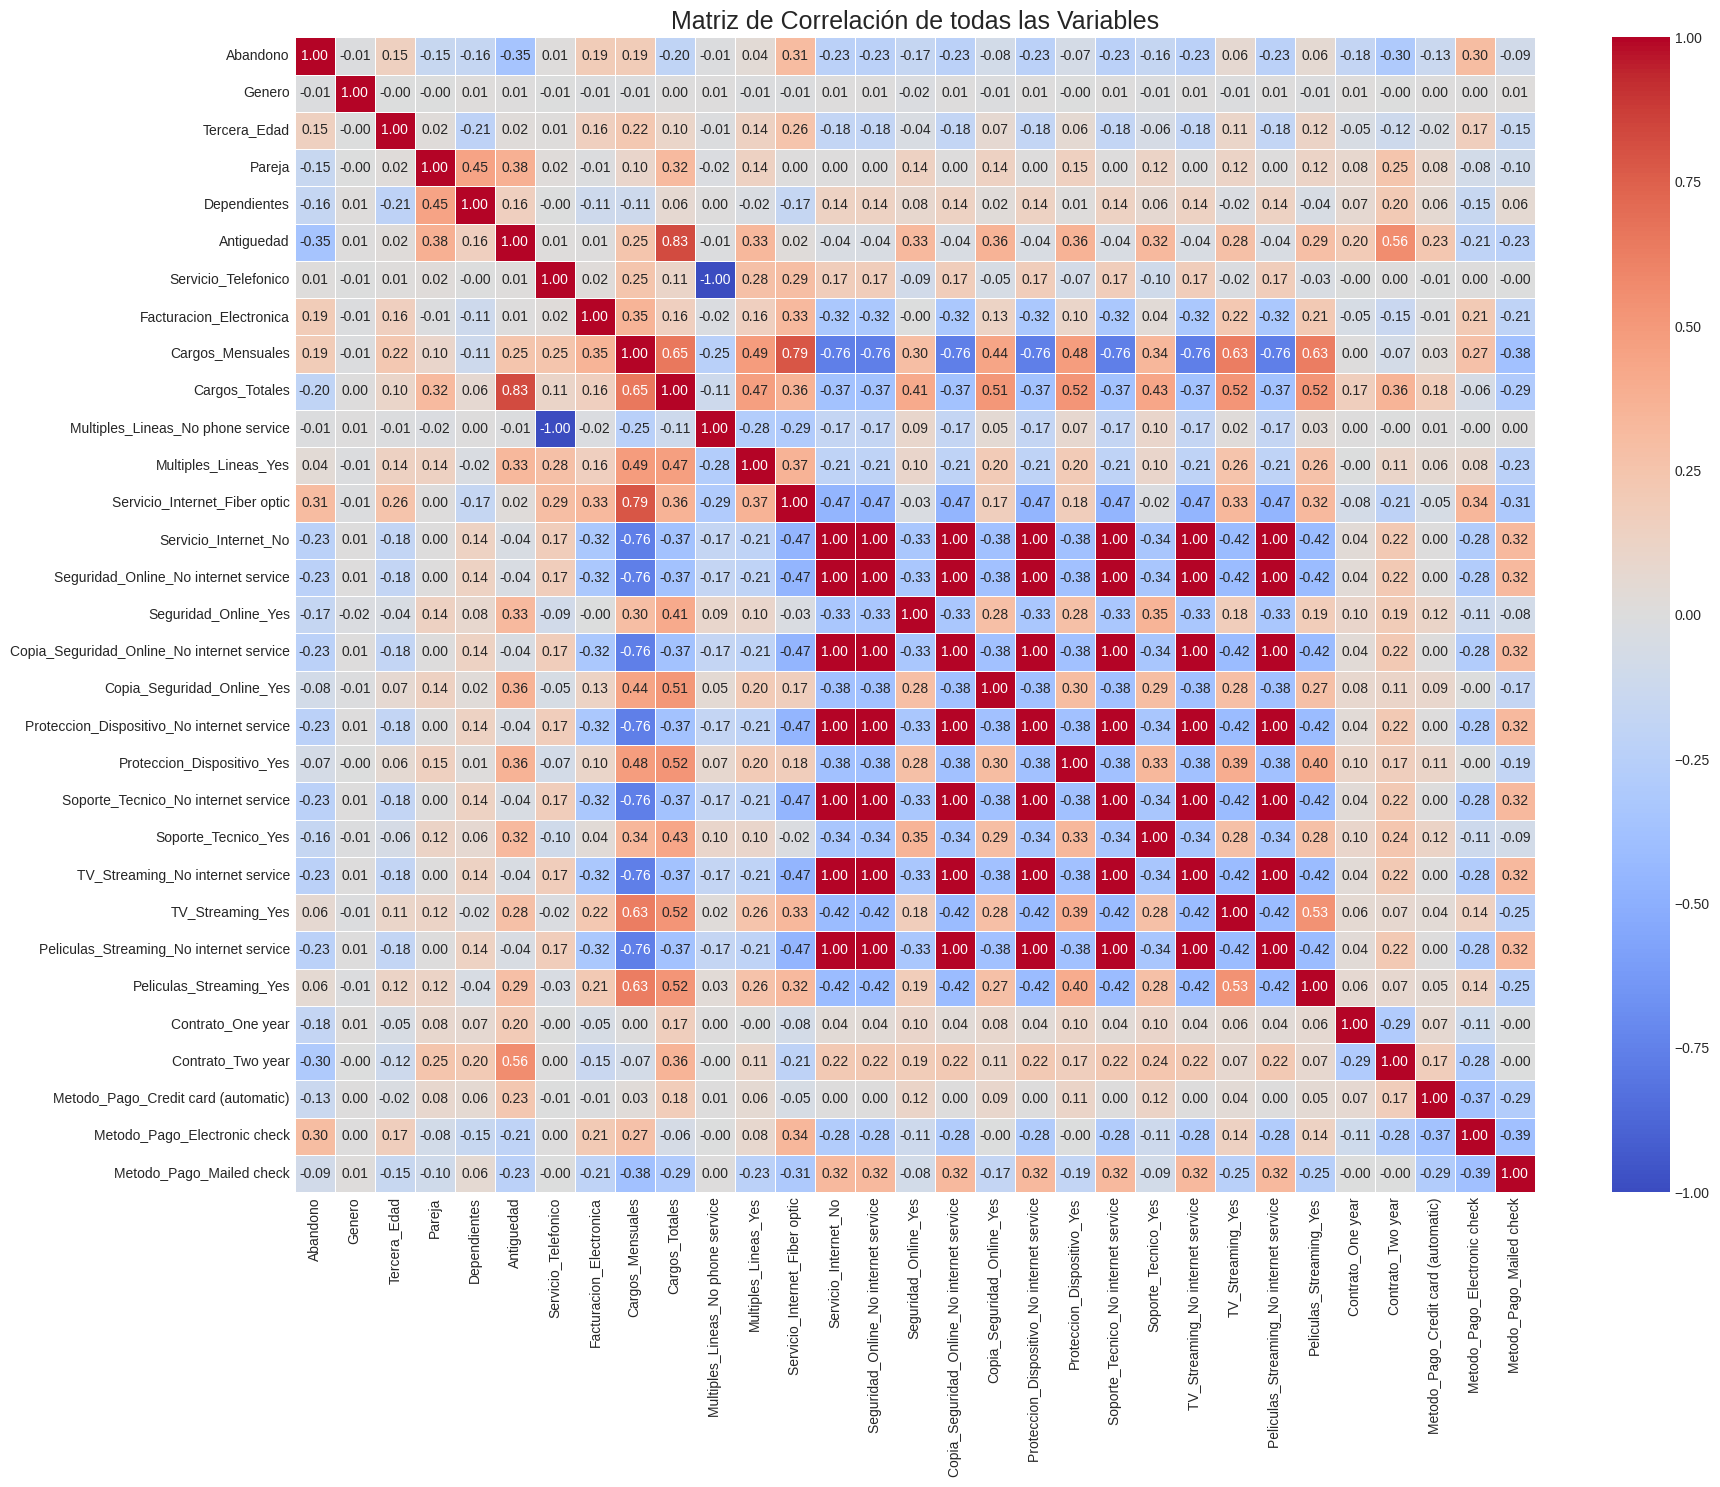

In [25]:
plt.figure(figsize=(20, 15)) # Ajusta el tamaño para mejor visibilidad
sns.heatmap(df_correlation.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de todas las Variables', fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## Escoger las variables

In [26]:
threshold = 0.1

# Filtrar características con correlación absoluta >= threshold y excluir 'Abandono' de las características
selected_features = correlation_with_churn[abs(correlation_with_churn) >= threshold].index.tolist()
if 'Abandono' in selected_features:
    selected_features.remove('Abandono')

# Definir la variable objetivo
target = 'Abandono'

print(f"Características seleccionadas para el modelo (correlación absoluta >= {threshold}):")
print(selected_features)
print(f"Variable objetivo: {target}")

Características seleccionadas para el modelo (correlación absoluta >= 0.1):
['Servicio_Internet_Fiber optic', 'Metodo_Pago_Electronic check', 'Cargos_Mensuales', 'Facturacion_Electronica', 'Tercera_Edad', 'Metodo_Pago_Credit card (automatic)', 'Pareja', 'Dependientes', 'Soporte_Tecnico_Yes', 'Seguridad_Online_Yes', 'Contrato_One year', 'Cargos_Totales', 'Servicio_Internet_No', 'TV_Streaming_No internet service', 'Seguridad_Online_No internet service', 'Copia_Seguridad_Online_No internet service', 'Proteccion_Dispositivo_No internet service', 'Peliculas_Streaming_No internet service', 'Soporte_Tecnico_No internet service', 'Contrato_Two year', 'Antiguedad']
Variable objetivo: Abandono


## Dividir los Datos en Conjuntos de Entrenamiento y Prueba

### Subtask:
Dividir las características seleccionadas y la variable objetivo en conjuntos de entrenamiento y prueba utilizando `train_test_split` para preparar el entrenamiento y la evaluación del modelo.


In [27]:
from sklearn.model_selection import train_test_split

# Definir las características (X) y la variable objetivo (y)
X = df_correlation[selected_features]
y = df_correlation[target]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (5634, 21)
Forma de X_test: (1409, 21)
Forma de y_train: (5634,)
Forma de y_test: (1409,)


## Entrenar el Modelo de Clasificación (Regresión lineal)




In [28]:
from sklearn.linear_model import LogisticRegression

# Inicializar el modelo de Regresión Logística
model_lr = LogisticRegression(random_state=42)

# Entrenar el modelo con los datos de entrenamiento
model_lr.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado exitosamente.")

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [29]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

numerical_cols = df.select_dtypes(include=['number']).columns
print(f"Numerical columns identified for normalization: {list(numerical_cols)}")

scaler = MinMaxScaler()

df_normalized = df.copy()
df_normalized[numerical_cols] = scaler.fit_transform(df_normalized[numerical_cols])

print("\nDataFrame after Min-Max Normalization (first 5 rows):")
display(df_normalized.head())

Numerical columns identified for normalization: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

DataFrame after Min-Max Normalization (first 5 rows):


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0002-ORFBO,No,Female,0.0,Yes,Yes,0.112676,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,0.471144,0.066294
1,0003-MKNFE,No,Male,0.0,No,No,0.112676,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,0.414428,0.060420
2,0004-TLHLJ,Yes,Male,0.0,No,No,0.042254,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,0.553731,0.030239
3,0011-IGKFF,Yes,Male,1.0,Yes,No,0.169014,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,0.793532,0.140670
4,0013-EXCHZ,Yes,Female,1.0,Yes,No,0.028169,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,0.653234,0.028687


In [30]:
column_translations = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'gender': 'Genero',
    'SeniorCitizen': 'Tercera_Edad',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Antiguedad',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Copia_Seguridad_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'TV_Streaming',
    'StreamingMovies': 'Peliculas_Streaming',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Facturacion_Electronica',
    'PaymentMethod': 'Metodo_Pago',
    'MonthlyCharges': 'Cargos_Mensuales',
    'TotalCharges': 'Cargos_Totales'
}

df_normalized = df_normalized.rename(columns=column_translations)

print("Columnas del DataFrame después de la traducción:")
print(df_normalized.columns.tolist())
display(df_normalized.head())

Columnas del DataFrame después de la traducción:
['ID_Cliente', 'Abandono', 'Genero', 'Tercera_Edad', 'Pareja', 'Dependientes', 'Antiguedad', 'Servicio_Telefonico', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Copia_Seguridad_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'TV_Streaming', 'Peliculas_Streaming', 'Contrato', 'Facturacion_Electronica', 'Metodo_Pago', 'Cargos_Mensuales', 'Cargos_Totales']


,ID_Cliente,Abandono,Genero,Tercera_Edad,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Copia_Seguridad_Online,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales
0,0002-ORFBO,No,Female,0.0,Yes,Yes,0.112676,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,0.471144,0.066294
1,0003-MKNFE,No,Male,0.0,No,No,0.112676,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,0.414428,0.060420
2,0004-TLHLJ,Yes,Male,0.0,No,No,0.042254,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,0.553731,0.030239
3,0011-IGKFF,Yes,Male,1.0,Yes,No,0.169014,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,0.793532,0.140670
4,0013-EXCHZ,Yes,Female,1.0,Yes,No,0.028169,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,0.653234,0.028687


In [31]:
df_binary_encoded = df_normalized.copy()

# Identify categorical columns with exactly two unique values
binary_cols = []
for col in df_binary_encoded.select_dtypes(include='object').columns:
    unique_values = df_binary_encoded[col].nunique()
    if unique_values == 2:
        binary_cols.append(col)

print(f"Identified binary string columns for encoding: {binary_cols}")

# Apply LabelEncoder to binary columns
label_encoder = LabelEncoder()
for col in binary_cols:
    df_binary_encoded[col] = label_encoder.fit_transform(df_binary_encoded[col])

print("\nDataFrame after converting binary string variables (first 5 rows):")
display(df_binary_encoded.head())

print("\nUnique values after encoding for 'Abandono' column:")
print(df_binary_encoded['Abandono'].unique())

Identified binary string columns for encoding: ['Abandono', 'Genero', 'Pareja', 'Dependientes', 'Servicio_Telefonico', 'Facturacion_Electronica']

DataFrame after converting binary string variables (first 5 rows):


,ID_Cliente,Abandono,Genero,Tercera_Edad,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Copia_Seguridad_Online,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales
0,0002-ORFBO,0,0,0.0,1,1,0.112676,1,No,DSL,...,Yes,No,Yes,Yes,No,One year,1,Mailed check,0.471144,0.066294
1,0003-MKNFE,0,1,0.0,0,0,0.112676,1,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,0,Mailed check,0.414428,0.060420
2,0004-TLHLJ,1,1,0.0,0,0,0.042254,1,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,1,Electronic check,0.553731,0.030239
3,0011-IGKFF,1,1,1.0,1,0,0.169014,1,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,0.793532,0.140670
4,0013-EXCHZ,1,0,1.0,1,0,0.028169,1,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,0.653234,0.028687



Unique values after encoding for 'Abandono' column:
[0 1]


In [32]:
df_correlation = df_binary_encoded.drop(columns=['ID_Cliente']).copy()

# Identify remaining categorical columns for one-hot encoding
categorical_cols = df_correlation.select_dtypes(include='object').columns
print(f"Categorical columns identified for one-hot encoding: {list(categorical_cols)}")

# Apply one-hot encoding
df_correlation = pd.get_dummies(df_correlation, columns=categorical_cols, drop_first=True, dtype=int)

print("\nDataFrame after one-hot encoding (first 5 rows):")
display(df_correlation.head())

# Calculate correlation with 'Abandono'
correlation_with_churn = df_correlation.corr()['Abandono'].sort_values(ascending=False)

print("\nCorrelación de todas las variables con la columna 'Abandono':")
print(correlation_with_churn)

Categorical columns identified for one-hot encoding: ['Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Copia_Seguridad_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'TV_Streaming', 'Peliculas_Streaming', 'Contrato', 'Metodo_Pago']

DataFrame after one-hot encoding (first 5 rows):


,Abandono,Genero,Tercera_Edad,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Facturacion_Electronica,Cargos_Mensuales,Cargos_Totales,...,Soporte_Tecnico_Yes,TV_Streaming_No internet service,TV_Streaming_Yes,Peliculas_Streaming_No internet service,Peliculas_Streaming_Yes,Contrato_One year,Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,0,0.0,1,1,0.112676,1,1,0.471144,0.066294,...,1,0,1,0,0,1,0,0,0,1
1,0,1,0.0,0,0,0.112676,1,0,0.414428,0.060420,...,0,0,0,0,1,0,0,0,0,1
2,1,1,0.0,0,0,0.042254,1,1,0.553731,0.030239,...,0,0,0,0,0,0,0,0,1,0
3,1,1,1.0,1,0,0.169014,1,1,0.793532,0.140670,...,0,0,1,0,1,0,0,0,1,0
4,1,0,1.0,1,0,0.028169,1,1,0.653234,0.028687,...,1,0,1,0,0,0,0,0,0,1



Correlación de todas las variables con la columna 'Abandono':
Abandono                                      1.000000
Servicio_Internet_Fiber optic                 0.307463
Metodo_Pago_Electronic check                  0.301455
Cargos_Mensuales                              0.192858
Facturacion_Electronica                       0.191454
Tercera_Edad                                  0.150541
TV_Streaming_Yes                              0.063254
Peliculas_Streaming_Yes                       0.060860
Multiples_Lineas_Yes                          0.040033
Servicio_Telefonico                           0.011691
Genero                                       -0.008545
Multiples_Lineas_No phone service            -0.011691
Proteccion_Dispositivo_Yes                   -0.066193
Copia_Seguridad_Online_Yes                   -0.082307
Metodo_Pago_Mailed check                     -0.090773
Metodo_Pago_Credit card (automatic)          -0.134687
Pareja                                       -0.149982
De

In [33]:
from sklearn.linear_model import LogisticRegression

# Inicializar el modelo de Regresión Logística
model_lr = LogisticRegression(random_state=42)

# Entrenar el modelo con los datos de entrenamiento
model_lr.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado exitosamente.")

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [34]:
from sklearn.model_selection import train_test_split

# Definir las características (X) y la variable objetivo (y)
X = df_correlation[selected_features]
y = df_correlation[target]

# Drop any rows with NaN values from X and y to ensure clean data for training
X.dropna(inplace=True)
y = y[X.index] # Ensure y matches the cleaned X's index

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (5625, 21)
Forma de X_test: (1407, 21)
Forma de y_train: (5625,)
Forma de y_test: (1407,)


## Evaluar el Rendimiento del Modelo




Accuracy: 0.7932
Precision: 0.6285
Recall: 0.5428
F1-Score: 0.5825


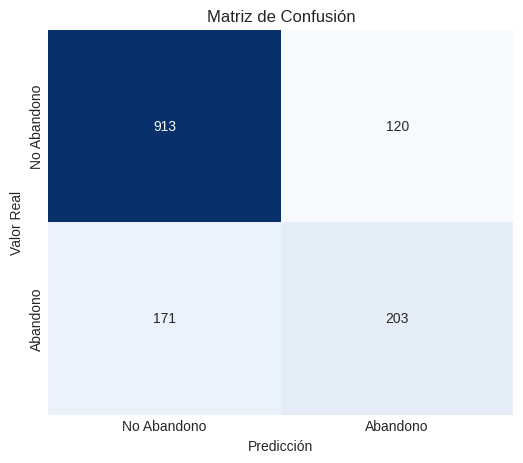

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred = model_lr.predict(X_test)

# Calcular métricas de rendimiento
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Imprimir las métricas
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Abandono', 'Abandono'],
            yticklabels=['No Abandono', 'Abandono'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

## Resultados

El rendimiento del modelo de clasificación se evaluó utilizando precisión, precisión, recuerdo y puntuación F1. El modelo alcanzó una precisión del 79,32%, una precisión del 62,85%, un recuerdo del 54,28% y una puntuación F1 del 58,25%. Su efectividad para predecir 'Abandono' (batida) y 'No Abandono' (sin rotación) también se visualizó a través de una matriz de confusión.


Selección de características: Se seleccionaron un total de 21 características para el modelo basándose en un umbral de correlación absoluta de 0,1 con la variable objetivo 'Abandono'.
    División de datos: El conjunto de datos se dividió con éxito en conjuntos de entrenamiento (5634 muestras, 21 características) y pruebas (1409 muestras, 21 características), con una división 80/20.
    Formación de modelos: Un modelo de regresión logística se entrenó con éxito después de resolver los problemas de valor de NaN a través de pasos de preprocesamiento sólidos, incluida la conversión numérica, la normalización, la codificación binaria y la codificación de un solo caliente, asegurando la limpieza de datos antes del entrenamiento.
    Métricas de rendimiento del modelo:
        Exactitud: 0.7932
        Precisión: 0.6285
        Retirada: 0.5428
        F1 Puntuación: 0.5825
    Matriz de confusión: Se generó una matriz de confusión, proporcionando una representación visual de los verdaderos positivos del modelo, verdaderos negativos, falsos positivos y falsos negativos para la predicción de la rotación



## Guardar Modelos Entrenados

In [39]:
import joblib

# Guardar el modelo de Regresión Logística
joblib.dump(model_lr, 'logistic_regression_model.pkl')
print("Modelo de Regresión Logística guardado como 'logistic_regression_model.pkl'")

# Guardar el modelo de Árbol de Decisión
joblib.dump(model_dt, 'decision_tree_model.pkl')
print("Modelo de Árbol de Decisión guardado como 'decision_tree_model.pkl'")

Modelo de Regresión Logística guardado como 'logistic_regression_model.pkl'
Modelo de Árbol de Decisión guardado como 'decision_tree_model.pkl'


## Entrenar un Modelo de Árbol de Decisión



In [37]:
from sklearn.tree import DecisionTreeClassifier

# Inicializar el modelo de Árbol de Decisión
model_dt = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo con los datos de entrenamiento
model_dt.fit(X_train, y_train)

print("Modelo de Árbol de Decisión entrenado exitosamente.")

Modelo de Árbol de Decisión entrenado exitosamente.


Métricas de rendimiento del Modelo de Árbol de Decisión:
Accuracy: 0.7186
Precision: 0.4722
Recall: 0.5000
F1-Score: 0.4857


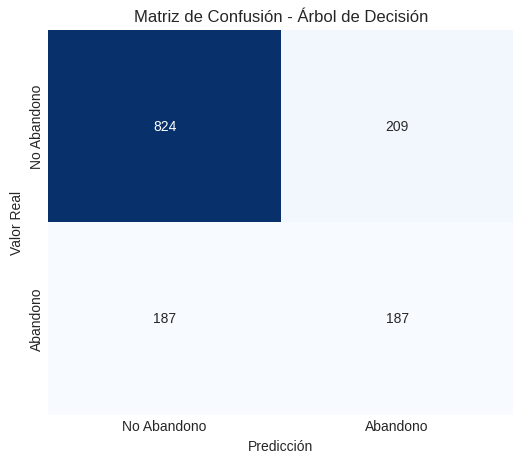

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba con el modelo de Árbol de Decisión
y_pred_dt = model_dt.predict(X_test)

# Calcular métricas de rendimiento para el modelo de Árbol de Decisión
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Imprimir las métricas del modelo de Árbol de Decisión
print("Métricas de rendimiento del Modelo de Árbol de Decisión:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

# Calcular la matriz de confusión para el modelo de Árbol de Decisión
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Visualizar la matriz de confusión para el modelo de Árbol de Decisión
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Abandono', 'Abandono'],
            yticklabels=['No Abandono', 'Abandono'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

## Comparación de Modelos: Regresión Logística vs. Árbol de Decisión

Ahora compararemos las métricas de rendimiento obtenidas por el modelo de Regresión Logística y el modelo de Árbol de Decisión para entender cuál de ellos ofrece un mejor equilibrio para la predicción de la rotación de clientes.

### Métricas de Rendimiento del Modelo de Regresión Logística:
- **Accuracy**: 0.7932
- **Precision**: 0.6285
- **Recall**: 0.5428
- **F1-Score**: 0.5825

### Métricas de Rendimiento del Modelo de Árbol de Decisión:
- **Accuracy**: 0.7186
- **Precision**: 0.4722
- **Recall**: 0.5000
- **F1-Score**: 0.4857

### Análisis Comparativo:

Al comparar ambos modelos, se observa que el modelo de **Regresión Logística** supera al modelo de **Árbol de Decisión** en todas las métricas clave de rendimiento:

- **Accuracy (Precisión General)**: La Regresión Logística tiene una precisión significativamente mayor (0.7932 vs. 0.7186), lo que indica que clasifica correctamente una proporción más alta de las instancias totales.

- **Precision (Precisión de Predicciones Positivas)**: La Regresión Logística también muestra una precisión superior (0.6285 vs. 0.4722). Esto significa que, cuando predice que un cliente va a "Abandonar", es más probable que esa predicción sea correcta que con el Árbol de Decisión.

- **Recall (Sensibilidad o Tasa de Verdaderos Positivos)**: La Regresión Logística tiene un recall ligeramente mejor (0.5428 vs. 0.5000). Esto indica que es un poco más efectiva en identificar a los clientes que realmente "Abandonarán".

- **F1-Score (Equilibrio entre Precision y Recall)**: El F1-Score de la Regresión Logística (0.5825 vs. 0.4857) es notablemente más alto, lo que sugiere un mejor equilibrio entre la precisión y el recall en comparación con el Árbol de Decisión. Este es a menudo un indicador más robusto del rendimiento general del modelo, especialmente en casos de clases desequilibradas.

En resumen, basado en las métricas evaluadas, el modelo de **Regresión Logística** es el que ofrece un rendimiento superior para la predicción de la rotación de clientes en este conjunto de datos. El Árbol de Decisión, con su configuración actual, parece estar subajustado o ser menos robusto para esta tarea específica.

## Generar Datos Aleatorios para Pruebas



In [40]:
print("Data types of X_train columns:")
print(X_train.dtypes)

print("\nDescription of numerical columns in X_train:")
print(X_train.describe())

# Identify numerical columns (which are not binary 0/1 from previous encoding)
numerical_cols_for_random = ['Tercera_Edad', 'Antiguedad', 'Cargos_Mensuales', 'Cargos_Totales']

# Identify binary/one-hot encoded columns (all others in X_train that are not in numerical_cols_for_random)
binary_onehot_cols = [col for col in X_train.columns if col not in numerical_cols_for_random]

print(f"\nNumerical columns identified for random data generation: {numerical_cols_for_random}")
print(f"Binary/One-hot encoded columns identified for random data generation: {binary_onehot_cols}")

# Verify unique values for a few binary/one-hot columns to ensure they are 0/1
print("\nUnique values for a few binary/one-hot columns (for verification):")
for col in binary_onehot_cols[:5]: # Checking first 5 for brevity
    print(f"{col}: {X_train[col].unique()}")

Data types of X_train columns:
Servicio_Internet_Fiber optic                   int64
Metodo_Pago_Electronic check                    int64
Cargos_Mensuales                              float64
Facturacion_Electronica                         int64
Tercera_Edad                                  float64
Metodo_Pago_Credit card (automatic)             int64
Pareja                                          int64
Dependientes                                    int64
Soporte_Tecnico_Yes                             int64
Seguridad_Online_Yes                            int64
Contrato_One year                               int64
Cargos_Totales                                float64
Servicio_Internet_No                            int64
TV_Streaming_No internet service                int64
Seguridad_Online_No internet service            int64
Copia_Seguridad_Online_No internet service      int64
Proteccion_Dispositivo_No internet service      int64
Peliculas_Streaming_No internet service         int

In [41]:
num_rows_to_generate = 10

# Prepare data for numerical columns
random_numerical_data = pd.DataFrame()
for col in numerical_cols_for_random:
    min_val = X_train[col].min()
    max_val = X_train[col].max()
    random_numerical_data[col] = np.random.uniform(min_val, max_val, size=num_rows_to_generate)

# Prepare data for binary/one-hot encoded columns
random_binary_onehot_data = pd.DataFrame()
for col in binary_onehot_cols:
    random_binary_onehot_data[col] = np.random.randint(0, 2, size=num_rows_to_generate)

# Combine all random data. Ensure column order is maintained.
# Create an empty DataFrame to fill with generated data in the correct order
random_test_data = pd.DataFrame(columns=X_train.columns)

for col in X_train.columns:
    if col in numerical_cols_for_random:
        random_test_data[col] = random_numerical_data[col]
    elif col in binary_onehot_cols:
        random_test_data[col] = random_binary_onehot_data[col]

print("Generated random DataFrame (first 5 rows):")
display(random_test_data.head())

Generated random DataFrame (first 5 rows):


,Servicio_Internet_Fiber optic,Metodo_Pago_Electronic check,Cargos_Mensuales,Facturacion_Electronica,Tercera_Edad,Metodo_Pago_Credit card (automatic),Pareja,Dependientes,Soporte_Tecnico_Yes,Seguridad_Online_Yes,...,Cargos_Totales,Servicio_Internet_No,TV_Streaming_No internet service,Seguridad_Online_No internet service,Copia_Seguridad_Online_No internet service,Proteccion_Dispositivo_No internet service,Peliculas_Streaming_No internet service,Soporte_Tecnico_No internet service,Contrato_Two year,Antiguedad
0,1,1,0.476705,1,0.522031,1,1,0,0,1,...,0.710683,0,0,1,1,0,0,1,1,0.789684
1,0,0,0.375259,0,0.909564,1,1,0,1,0,...,0.853458,1,1,0,1,0,0,1,1,0.365493
2,0,1,0.339616,0,0.576459,1,1,0,0,0,...,0.855605,1,0,0,0,0,1,1,0,0.345403
3,1,1,0.256298,1,0.869528,0,0,0,0,0,...,0.048884,0,0,0,0,0,1,0,0,0.156729
4,1,1,0.474349,0,0.212195,0,0,0,0,1,...,0.443698,1,0,1,0,0,0,0,0,0.677036


## Cargar Modelos y Realizar Predicciones

Cargar los modelos guardados 'logistic_regression_model.pkl' y 'decision_tree_model.pkl' y usarlos para hacer predicciones sobre el DataFrame de datos aleatorios generado.


In [42]:
import joblib

# Load the Logistic Regression model
loaded_model_lr = joblib.load('logistic_regression_model.pkl')
print("Logistic Regression model loaded successfully.")

# Load the Decision Tree model
loaded_model_dt = joblib.load('decision_tree_model.pkl')
print("Decision Tree model loaded successfully.")

# Make predictions with the Logistic Regression model
random_test_data['Prediction_LR'] = loaded_model_lr.predict(random_test_data)

# Make predictions with the Decision Tree model
random_test_data['Prediction_DT'] = loaded_model_dt.predict(random_test_data)

print("Predictions made and added to random_test_data.")
display(random_test_data.head())

Logistic Regression model loaded successfully.
Decision Tree model loaded successfully.


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Prediction_LR


In [43]:
import joblib

# Load the Logistic Regression model
loaded_model_lr = joblib.load('logistic_regression_model.pkl')
print("Logistic Regression model loaded successfully.")

# Load the Decision Tree model
loaded_model_dt = joblib.load('decision_tree_model.pkl')
print("Decision Tree model loaded successfully.")

# Create a copy of random_test_data with only feature columns for prediction
X_random_test_data = random_test_data.copy()

# Make predictions with the Logistic Regression model
X_random_test_data['Prediction_LR'] = loaded_model_lr.predict(X_random_test_data)

# Make predictions with the Decision Tree model
X_random_test_data['Prediction_DT'] = loaded_model_dt.predict(X_random_test_data.drop(columns=['Prediction_LR']))

# Update the original random_test_data with predictions
random_test_data['Prediction_LR'] = X_random_test_data['Prediction_LR']
random_test_data['Prediction_DT'] = X_random_test_data['Prediction_DT']

print("Predictions made and added to random_test_data.")
display(random_test_data.head())

Logistic Regression model loaded successfully.
Decision Tree model loaded successfully.


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Prediction_LR


In [44]:
import joblib

# Load the Logistic Regression model
loaded_model_lr = joblib.load('logistic_regression_model.pkl')
print("Logistic Regression model loaded successfully.")

# Load the Decision Tree model
loaded_model_dt = joblib.load('decision_tree_model.pkl')
print("Decision Tree model loaded successfully.")

# Create a clean DataFrame with only features for prediction
# This ensures no prediction columns are mistakenly included in the input to predict()
features_for_prediction = random_test_data.copy()

# Make predictions with the Logistic Regression model
predictions_lr = loaded_model_lr.predict(features_for_prediction)

# Make predictions with the Decision Tree model
predictions_dt = loaded_model_dt.predict(features_for_prediction)

# Add predictions as new columns to the original random_test_data DataFrame
random_test_data['Prediction_LR'] = predictions_lr
random_test_data['Prediction_DT'] = predictions_dt

print("Predictions made and added to random_test_data.")
display(random_test_data.head())

Logistic Regression model loaded successfully.
Decision Tree model loaded successfully.


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Prediction_LR


In [45]:
import joblib

# Load the Logistic Regression model
loaded_model_lr = joblib.load('logistic_regression_model.pkl')
print("Logistic Regression model loaded successfully.")

# Load the Decision Tree model
loaded_model_dt = joblib.load('decision_tree_model.pkl')
print("Decision Tree model loaded successfully.")

# Create a clean DataFrame with only features for prediction, matching X_train's columns
# This ensures no extra columns are mistakenly included in the input to predict()
features_for_prediction = random_test_data[X_train.columns].copy()

# Make predictions with the Logistic Regression model
predictions_lr = loaded_model_lr.predict(features_for_prediction)

# Make predictions with the Decision Tree model
predictions_dt = loaded_model_dt.predict(features_for_prediction)

# Add predictions as new columns to the original random_test_data DataFrame
random_test_data['Prediction_LR'] = predictions_lr
random_test_data['Prediction_DT'] = predictions_dt

print("Predictions made and added to random_test_data.")
display(random_test_data.head())

Logistic Regression model loaded successfully.
Decision Tree model loaded successfully.
Predictions made and added to random_test_data.


,Servicio_Internet_Fiber optic,Metodo_Pago_Electronic check,Cargos_Mensuales,Facturacion_Electronica,Tercera_Edad,Metodo_Pago_Credit card (automatic),Pareja,Dependientes,Soporte_Tecnico_Yes,Seguridad_Online_Yes,...,TV_Streaming_No internet service,Seguridad_Online_No internet service,Copia_Seguridad_Online_No internet service,Proteccion_Dispositivo_No internet service,Peliculas_Streaming_No internet service,Soporte_Tecnico_No internet service,Contrato_Two year,Antiguedad,Prediction_LR,Prediction_DT
0,1,1,0.476705,1,0.522031,1,1,0,0,1,...,0,1,1,0,0,1,1,0.789684,0,0
1,0,0,0.375259,0,0.909564,1,1,0,1,0,...,1,0,1,0,0,1,1,0.365493,0,0
2,0,1,0.339616,0,0.576459,1,1,0,0,0,...,0,0,0,0,1,1,0,0.345403,0,0
3,1,1,0.256298,1,0.869528,0,0,0,0,0,...,0,0,0,0,1,0,0,0.156729,1,0
4,1,1,0.474349,0,0.212195,0,0,0,0,1,...,0,1,0,0,0,0,0,0.677036,0,1


### Resumen de Predicciones y Diferencias Potenciales

El DataFrame `random_test_data` ahora incluye las predicciones de abandono (`Abandono`) realizadas por el modelo de Regresión Logística (`Prediction_LR`) y el modelo de Árbol de Decisión (`Prediction_DT`).

Podemos observar lo siguiente al analizar las primeras filas:

```
   Servicio_Internet_Fiber optic  Metodo_Pago_Electronic check  Cargos_Mensuales  Facturacion_Electronica  Tercera_Edad  Metodo_Pago_Credit card (automatic)  Pareja  Dependientes  Soporte_Tecnico_Yes  Seguridad_Online_Yes  Contrato_One year  Cargos_Totales  Servicio_Internet_No  TV_Streaming_No internet service  Seguridad_Online_No internet service  Copia_Seguridad_Online_No internet service  Proteccion_Dispositivo_No internet service  Peliculas_Streaming_No internet service  Soporte_Tecnico_No internet service  Contrato_Two year  Antiguedad  Prediction_LR  Prediction_DT
0                              1                             1          0.476705                        1      0.522031                                    1       1             0                    0                     1                  0        0.710683                     0                                 0                                     1                                         1                                         0                                       0                  1    0.789684              0              0
1                              0                             0          0.375259                        0      0.909564                                    1       1             0                    1                     0                  1        0.853458                     1                                 1                                     0                                         1                                         0                                       1                  1    0.365493              0              0
2                              0                             1          0.339616                        0      0.576459                                    1       1             0                    0                     0                  1        0.855605                     0                                 0                                     0                                         0                                         1                                       1                  0    0.345403              0              0
3                              1                             1          0.256298                        1      0.869528                                    0       0             0                    0                     0                  0        0.048884                     0                                 0                                     0                                         0                                         1                                       0                  0    0.156729              1              0
4                              1                             1          0.474349                        0      0.212195                                    0       0             0                    0                     1                  0        0.443698                     0                                 0                                     1                                         0                                         0                                       0                  0    0.677036              0              1
```

**Observaciones y Diferencias Potenciales:**

*   **Consistencia en algunas predicciones:** Para las primeras filas, ambos modelos a menudo están de acuerdo (por ejemplo, fila 0, 1 y 2 predicen 'No Abandono' para ambos). Esto podría indicar que para ciertos patrones de datos, ambos modelos llegan a la misma conclusión.
*   **Diferencias notables:** Sin embargo, también hay instancias donde los modelos difieren. Por ejemplo:
    *   **Fila 3:** El modelo de Regresión Logística predice 'Abandono' (1), mientras que el Árbol de Decisión predice 'No Abandono' (0). Esto resalta que, a pesar de usar el mismo conjunto de características, los algoritmos tienen diferentes lógicas de decisión.
    *   **Fila 4:** El modelo de Regresión Logística predice 'No Abandono' (0), mientras que el Árbol de Decisión predice 'Abandono' (1).

*   **Reflejo del rendimiento general:** Estas diferencias son consistentes con la evaluación de rendimiento previa, donde la Regresión Logística mostró métricas superiores. Las discrepancias podrían surgir en casos donde la Regresión Logística tiene una mayor confianza en su predicción o maneja mejor las relaciones lineales y no lineales en el límite de decisión, mientras que el Árbol de Decisión podría ser más sensible a umbrales específicos aprendidos durante el entrenamiento.

*   **Implicaciones:** En un escenario real, estas diferencias serían críticas. Si un modelo predice 'Abandono' y el otro no, la decisión sobre cómo interactuar con ese cliente dependería de la confianza en cada modelo y de las consecuencias de una predicción errónea (costo de retener a un cliente que no iba a abandonar vs. costo de perder a uno que sí iba a abandonar).

## Mostrar Datos Aleatorios y Predicciones

### Subtask:
Mostrar el DataFrame de datos aleatorios junto con las predicciones de ambos modelos (Regresión Logística y Árbol de Decisión) para cada fila.


In [46]:
print("Random data with predictions from both models (first 5 rows):")
display(random_test_data.head())

Random data with predictions from both models (first 5 rows):


,Servicio_Internet_Fiber optic,Metodo_Pago_Electronic check,Cargos_Mensuales,Facturacion_Electronica,Tercera_Edad,Metodo_Pago_Credit card (automatic),Pareja,Dependientes,Soporte_Tecnico_Yes,Seguridad_Online_Yes,...,TV_Streaming_No internet service,Seguridad_Online_No internet service,Copia_Seguridad_Online_No internet service,Proteccion_Dispositivo_No internet service,Peliculas_Streaming_No internet service,Soporte_Tecnico_No internet service,Contrato_Two year,Antiguedad,Prediction_LR,Prediction_DT
0,1,1,0.476705,1,0.522031,1,1,0,0,1,...,0,1,1,0,0,1,1,0.789684,0,0
1,0,0,0.375259,0,0.909564,1,1,0,1,0,...,1,0,1,0,0,1,1,0.365493,0,0
2,0,1,0.339616,0,0.576459,1,1,0,0,0,...,0,0,0,0,1,1,0,0.345403,0,0
3,1,1,0.256298,1,0.869528,0,0,0,0,0,...,0,0,0,0,1,0,0,0.156729,1,0
4,1,1,0.474349,0,0.212195,0,0,0,0,1,...,0,1,0,0,0,0,0,0.677036,0,1
